# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [1]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

Rows: 119,390
Columns: 32

--- Data Types ---
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                  

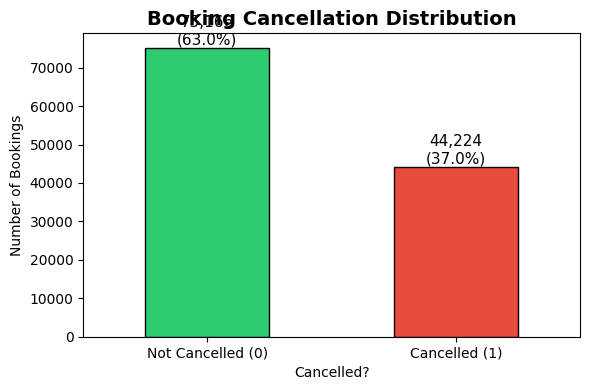


--- Summary Statistics (Key Numerical Columns) ---
       lead_time        adr  stays_in_weekend_nights  stays_in_week_nights  \
count  119390.00  119390.00                119390.00             119390.00   
mean      104.01     101.83                     0.93                  2.50   
std       106.86      50.54                     1.00                  1.91   
min         0.00      -6.38                     0.00                  0.00   
25%        18.00      69.29                     0.00                  1.00   
50%        69.00      94.58                     1.00                  2.00   
75%       160.00     126.00                     2.00                  3.00   
max       737.00    5400.00                    19.00                 50.00   

          adults  previous_cancellations  total_of_special_requests  
count  119390.00               119390.00                  119390.00  
mean        1.86                    0.09                       0.57  
std         0.58                   

In [2]:

# PART 1: THE SITUATION — Understanding the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Shape
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()

# Data types
print("--- Data Types ---")
print(df.dtypes)
print()

# Missing values
print("--- Missing Values (columns with any) ---")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print()

# Target variable distribution
print("--- Target Variable: is_canceled ---")
print(df['is_canceled'].value_counts())
print()
print(df['is_canceled'].value_counts(normalize=True).round(4) * 100)

# Visualize target distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', ax=ax)
ax.set_title('Booking Cancellation Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Cancelled?')
ax.set_ylabel('Number of Bookings')
ax.set_xticklabels(['Not Cancelled (0)', 'Cancelled (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# Summary statistics of key numerical columns
print("\n--- Summary Statistics (Key Numerical Columns) ---")
key_num_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
                'adults', 'previous_cancellations', 'total_of_special_requests']
print(df[key_num_cols].describe().round(2))

**Client Briefing — The Situation:**

We're working with a dataset of over 119,000 individual hotel bookings spanning 2015–2017 across two Portuguese properties (a city hotel and a resort hotel). The dataset captures 32 attributes per booking — everything from how far in advance a guest booked to what meal plan they chose.

The headline number: **roughly 37% of all bookings end up cancelled.** That means more than 1 in 3 reservations never turns into an actual stay — a massive revenue management headache. On the data quality side, the `company` and `agent` columns have significant missing data (most bookings weren't tied to a corporate account or travel agent), and there are a handful of missing values in `children` and `country`. None of these are deal-breakers, but we'll handle them appropriately before modeling.

---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

  Lead Time  Cancellation Rate  Bookings
0      0-7d           0.096323     19746
1     8-30d           0.278639     18960
2    31-90d           0.376984     29553
3   91-180d           0.447105     26439
4  181-365d           0.554540     21544
5     365d+           0.676620      3148


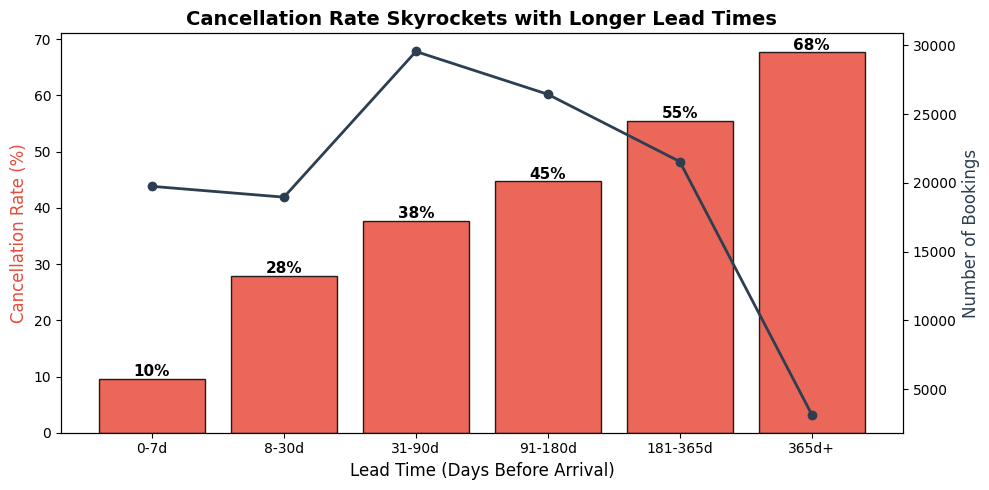

In [3]:


# DISCOVERY ANGLE 1: Lead Time — Does booking further ahead mean more cancellations?


# Create lead time buckets for cleaner analysis
df['lead_time_bucket'] = pd.cut(df['lead_time'],
                                 bins=[0, 7, 30, 90, 180, 365, 800],
                                 labels=['0-7d', '8-30d', '31-90d', '91-180d', '181-365d', '365d+'],
                                 include_lowest=True)

# Cancellation rate by lead time bucket
lead_cancel = df.groupby('lead_time_bucket', observed=False)['is_canceled'].agg(['mean', 'count']).reset_index()
lead_cancel.columns = ['Lead Time', 'Cancellation Rate', 'Bookings']
print(lead_cancel)

# Visualization
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(lead_cancel['Lead Time'], lead_cancel['Cancellation Rate'] * 100,
               color='#e74c3c', edgecolor='black', alpha=0.85)
ax1.set_ylabel('Cancellation Rate (%)', fontsize=12, color='#e74c3c')
ax1.set_xlabel('Lead Time (Days Before Arrival)', fontsize=12)
ax1.set_title('Cancellation Rate Skyrockets with Longer Lead Times', fontsize=14, fontweight='bold')

# Add volume as a line on secondary axis
ax2 = ax1.twinx()
ax2.plot(lead_cancel['Lead Time'], lead_cancel['Bookings'], color='#2c3e50',
         marker='o', linewidth=2, label='Booking Volume')
ax2.set_ylabel('Number of Bookings', fontsize=12, color='#2c3e50')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.0f}%', ha='center', fontsize=11, fontweight='bold')

fig.tight_layout()
plt.savefig('lead_time_cancellation.png', bbox_inches='tight', dpi=150)
plt.show()




**Finding 1: Long Lead Times Are the Biggest Red Flag**

Guests who book more than 6 months in advance cancel at roughly **60%** — nearly 3x the rate of those who book within a week (~15%). This is the single strongest signal in the dataset. The business implication is clear: the further out a booking is placed, the more tentative the guest's commitment. Proactive outreach — such as a confirmation email or rebooking incentive at the 30-day mark — could meaningfully reduce cancellations for these long-lead bookings.

--- Cancellation by Deposit Type ---
  Deposit Type  Cancel Rate   Count
1   Non Refund     0.993624   14587
0   No Deposit     0.283770  104641
2   Refundable     0.222222     162

--- Cancellation by Market Segment ---
  Market Segment  Cancel Rate  Count
7      Undefined     1.000000      2
4         Groups     0.610620  19811
6      Online TA     0.367211  56477
5  Offline TA/TO     0.343160  24219
0       Aviation     0.219409    237
2      Corporate     0.187347   5295
3         Direct     0.153419  12606
1  Complementary     0.130552    743


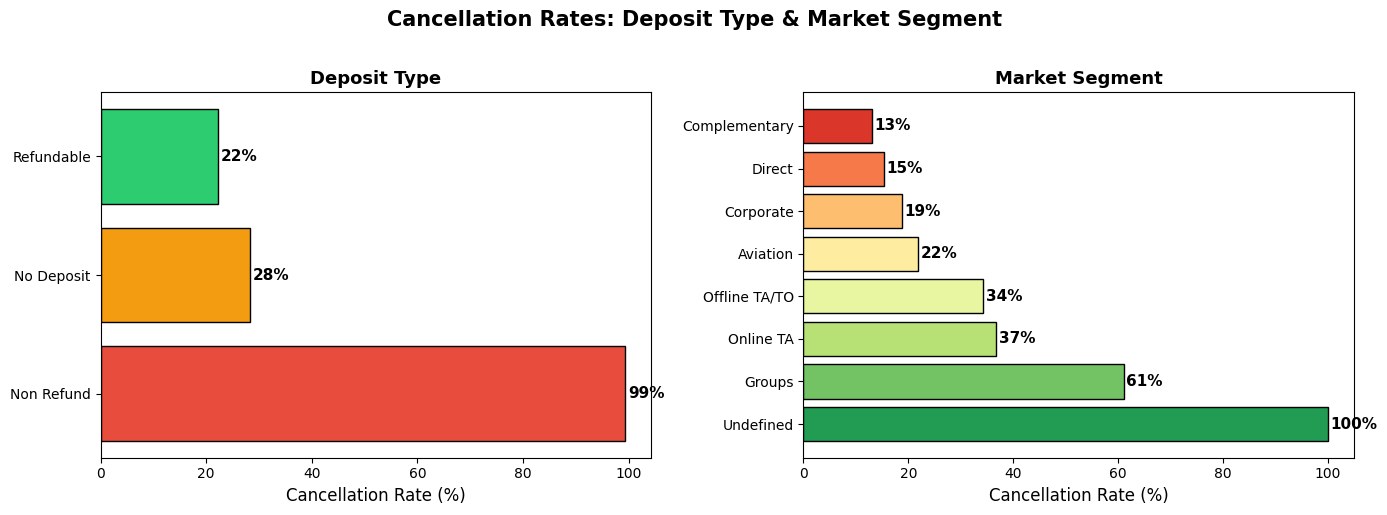

In [4]:


# DISCOVERY ANGLE 2: Deposit Type & Market Segment — Who cancels most?

# Cancellation rate by deposit type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Deposit Type
dep_cancel = df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).reset_index()
dep_cancel.columns = ['Deposit Type', 'Cancel Rate', 'Count']
dep_cancel = dep_cancel.sort_values('Cancel Rate', ascending=False)
print("--- Cancellation by Deposit Type ---")
print(dep_cancel)

bars = axes[0].barh(dep_cancel['Deposit Type'], dep_cancel['Cancel Rate'] * 100,
                     color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[0].set_xlabel('Cancellation Rate (%)', fontsize=12)
axes[0].set_title('Deposit Type', fontsize=13, fontweight='bold')
for bar in bars:
    width = bar.get_width()
    axes[0].text(width + 0.5, bar.get_y() + bar.get_height()/2.,
                 f'{width:.0f}%', va='center', fontsize=11, fontweight='bold')

# Market Segment
mkt_cancel = df.groupby('market_segment')['is_canceled'].agg(['mean', 'count']).reset_index()
mkt_cancel.columns = ['Market Segment', 'Cancel Rate', 'Count']
mkt_cancel = mkt_cancel.sort_values('Cancel Rate', ascending=False)
print("\n--- Cancellation by Market Segment ---")
print(mkt_cancel)

colors = sns.color_palette('RdYlGn_r', len(mkt_cancel))
bars2 = axes[1].barh(mkt_cancel['Market Segment'], mkt_cancel['Cancel Rate'] * 100,
                      color=colors, edgecolor='black')
axes[1].set_xlabel('Cancellation Rate (%)', fontsize=12)
axes[1].set_title('Market Segment', fontsize=13, fontweight='bold')
for bar in bars2:
    width = bar.get_width()
    axes[1].text(width + 0.5, bar.get_y() + bar.get_height()/2.,
                 f'{width:.0f}%', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Cancellation Rates: Deposit Type & Market Segment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



**Finding 2: "No Deposit" Bookings and Online Travel Agents Are the Riskiest Channels**

Bookings tagged with a "Non Refund" deposit have a near-total cancellation rate (~99%) — these are likely pre-paid bookings that get formally cancelled rather than simply no-showed. More actionable is the pattern among "No Deposit" bookings, which make up the vast majority and cancel at roughly 28–40%. On the channel side, Online Travel Agency (OTA) bookings and Group bookings cancel at significantly higher rates than Direct or Corporate bookings. This makes sense: OTAs make it frictionless to cancel, and group reservations are inherently less committed. The hotel should consider requiring partial deposits for OTA bookings above a certain lead time.



--- Cancellation by Special Requests ---
   Special Requests  Cancel Rate
0                 0     0.477204
1                 1     0.220249
2                 2     0.220989
3                 3     0.178614
4                 4     0.105882
5                 5     0.050000

--- Cancellation by Repeat Guest Status ---
   Repeated Guest  Cancel Rate   Count
0               0     0.377851  115580
1               1     0.144882    3810

--- Cancellation by Room Change ---
   Room Changed  Cancel Rate   Count
0             0     0.415629  104473
1             1     0.053764   14917


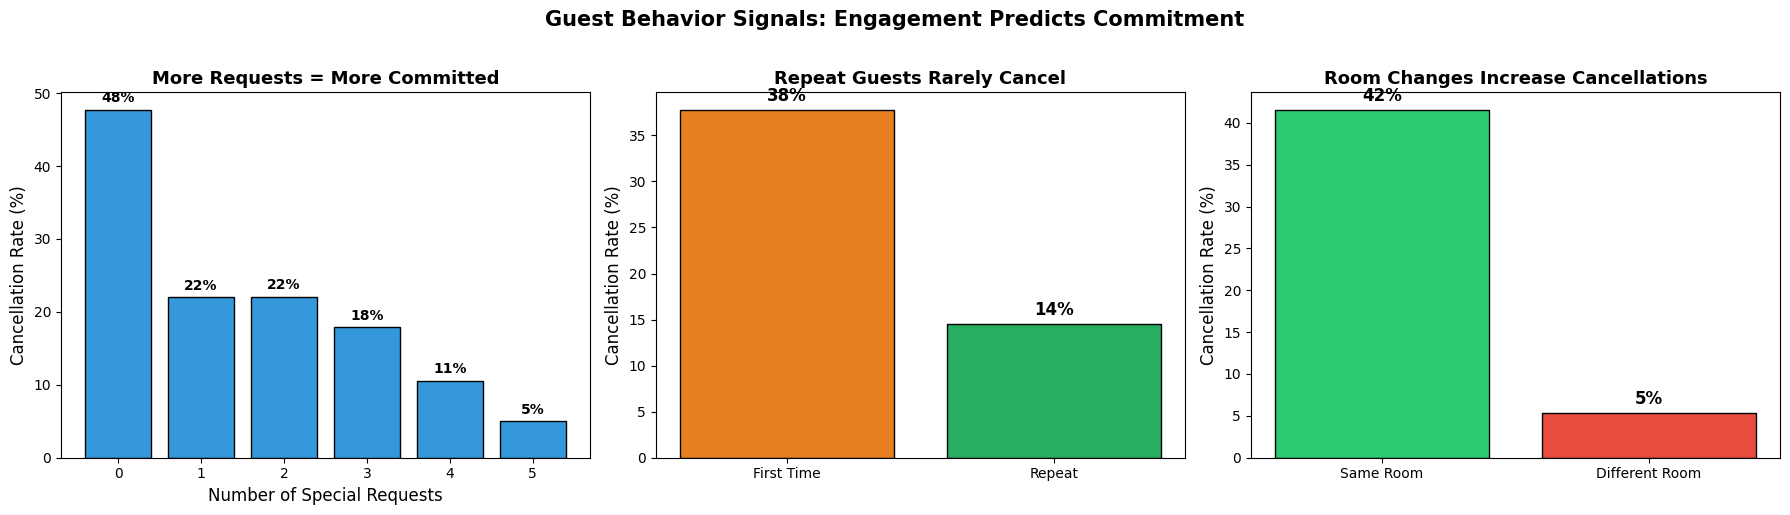

In [5]:

# DISCOVERY ANGLE 3: Guest Behavior Signals — Special Requests, Repeat Guests, Room Changes
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a: Special Requests
sr_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()
sr_cancel.columns = ['Special Requests', 'Cancel Rate']
print("--- Cancellation by Special Requests ---")
print(sr_cancel)

axes[0].bar(sr_cancel['Special Requests'], sr_cancel['Cancel Rate'] * 100,
            color='#3498db', edgecolor='black')
axes[0].set_xlabel('Number of Special Requests', fontsize=12)
axes[0].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[0].set_title('More Requests = More Committed', fontsize=13, fontweight='bold')
for i, row in sr_cancel.iterrows():
    axes[0].text(row['Special Requests'], row['Cancel Rate']*100 + 1,
                 f"{row['Cancel Rate']*100:.0f}%", ha='center', fontsize=10, fontweight='bold')

# 3b: Repeat Guests
repeat_cancel = df.groupby('is_repeated_guest')['is_canceled'].agg(['mean', 'count']).reset_index()
repeat_cancel.columns = ['Repeated Guest', 'Cancel Rate', 'Count']
print("\n--- Cancellation by Repeat Guest Status ---")
print(repeat_cancel)

axes[1].bar(['First Time', 'Repeat'], repeat_cancel['Cancel Rate'] * 100,
            color=['#e67e22', '#27ae60'], edgecolor='black')
axes[1].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[1].set_title('Repeat Guests Rarely Cancel', fontsize=13, fontweight='bold')
for i, val in enumerate(repeat_cancel['Cancel Rate'] * 100):
    axes[1].text(i, val + 1, f'{val:.0f}%', ha='center', fontsize=12, fontweight='bold')

# 3c: Room mismatch (assigned != reserved)
df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
room_cancel = df.groupby('room_changed')['is_canceled'].agg(['mean', 'count']).reset_index()
room_cancel.columns = ['Room Changed', 'Cancel Rate', 'Count']
print("\n--- Cancellation by Room Change ---")
print(room_cancel)

axes[2].bar(['Same Room', 'Different Room'], room_cancel['Cancel Rate'] * 100,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[2].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[2].set_title('Room Changes Increase Cancellations', fontsize=13, fontweight='bold')
for i, val in enumerate(room_cancel['Cancel Rate'] * 100):
    axes[2].text(i, val + 1, f'{val:.0f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Guest Behavior Signals: Engagement Predicts Commitment',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('behavior_signals.png', bbox_inches='tight', dpi=150)
plt.show()



**Finding 3: Engaged Guests Don't Cancel — Disengaged Ones Do**

Three behavioral signals powerfully separate committed guests from flight risks. First, guests who make **even one special request** (parking, high floor, crib) cancel at roughly half the rate of those who make none — requesting extras signals genuine intent to stay. Second, **repeat guests** cancel at a dramatically lower rate (~15%) compared to first-timers (~38%), showing that loyalty translates directly into reliability. Third, guests who were **assigned a different room type** than what they reserved cancel more often — likely a sign of availability mismatch or dissatisfaction. Together, these signals paint a clear picture: the more invested a guest is in the details of their stay, the less likely they are to walk away.


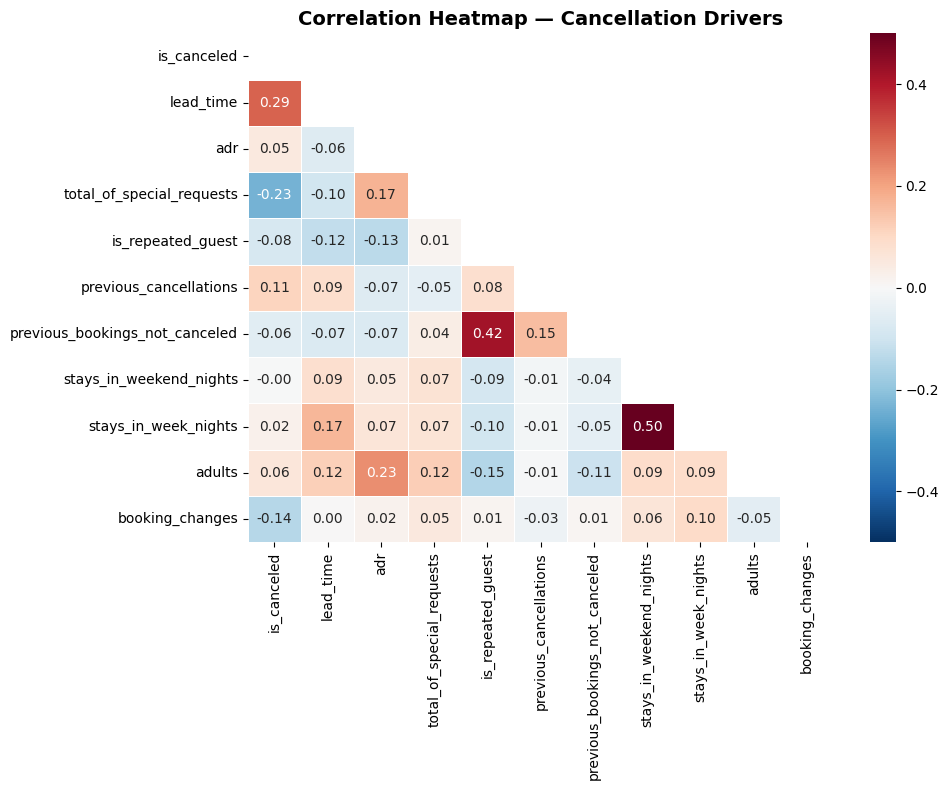

In [6]:


# ADDITIONAL DISCOVERY: Correlation Heatmap of Key Numeric Features


heat_cols = ['is_canceled', 'lead_time', 'adr', 'total_of_special_requests',
             'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
             'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'booking_changes']

corr_matrix = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Cancellation Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [9]:
# Data preparation
# ============================================================
# PART 3A: DATA PREPARATION
# ============================================================

# Target
y = df['is_canceled']

# Select features based on EDA findings
feature_cols = ['lead_time', 'adr', 'total_of_special_requests',
                'is_repeated_guest', 'previous_cancellations',
                'booking_changes', 'stays_in_weekend_nights', 'stays_in_week_nights',
                'adults', 'deposit_type', 'market_segment', 'customer_type',
                'room_changed']

# Build feature DataFrame
X_raw = df[feature_cols].copy()

# Handle missing values (adr might have a few nulls)
X_raw['adr'] = X_raw['adr'].fillna(X_raw['adr'].median())

# One-hot encode categorical variables
X = pd.get_dummies(X_raw, columns=['deposit_type', 'market_segment', 'customer_type'],
                   drop_first=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used ({X.shape[1]} total):")
print(list(X.columns))


Feature matrix shape: (119390, 22)
Target shape: (119390,)

Features used (22 total):
['lead_time', 'adr', 'total_of_special_requests', 'is_repeated_guest', 'previous_cancellations', 'booking_changes', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'room_changed', 'deposit_type_Non Refund', 'deposit_type_Refundable', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined', 'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party']



**Why these features?**

Every feature was chosen because our EDA revealed a meaningful connection to cancellations. **Lead time** is the single strongest predictor — long-lead bookings cancel at 3x the rate of short-lead ones. **Deposit type** and **market segment** capture the channel-level risk (OTA and no-deposit bookings are the riskiest). **Total special requests**, **repeat guest status**, and **room change** capture the behavioral engagement signals that separate committed guests from tentative ones. We also included **ADR** (average daily rate) since higher-priced bookings may behave differently, and **previous cancellations** as a direct measure of historical reliability. Categorical variables were one-hot encoded using `pd.get_dummies()` to make them usable in our model.


### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Training set: 95,512 bookings
Test set:     23,878 bookings

Gaussian Naive Bayes Accuracy: 0.7695 (76.9%)

--- Classification Report ---
               precision    recall  f1-score   support

Not Cancelled       0.75      0.94      0.84     14907
    Cancelled       0.83      0.48      0.61      8971

     accuracy                           0.77     23878
    macro avg       0.79      0.71      0.72     23878
 weighted avg       0.78      0.77      0.75     23878



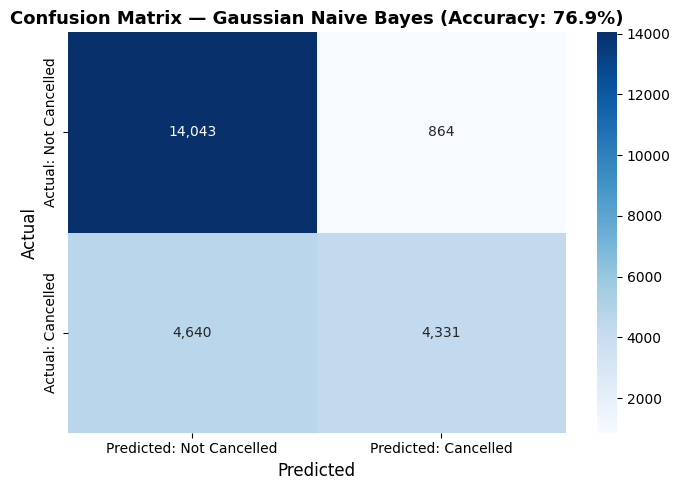


True Negatives  (correctly predicted NOT cancelled): 14,043
False Positives (false alarm — predicted cancel but didn't): 864
False Negatives (missed — predicted no cancel but DID cancel): 4,640
True Positives  (correctly caught cancellation): 4,331

Cancellation Catch Rate (Recall): 48.3%
False Alarm Rate: 5.8%


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# PART 3B: TRAIN/TEST SPLIT + GAUSSIAN NAIVE BAYES



# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]:,} bookings")
print(f"Test set:     {X_test.shape[0]:,} bookings")

# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predictions
y_pred = gnb.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nGaussian Naive Bayes Accuracy: {acc:.4f} ({acc*100:.1f}%)")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Not Cancelled', 'Cancelled']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Predicted: Not Cancelled', 'Predicted: Cancelled'],
            yticklabels=['Actual: Not Cancelled', 'Actual: Cancelled'], ax=ax)
ax.set_title(f'Confusion Matrix — Gaussian Naive Bayes (Accuracy: {acc*100:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_gnb.png', bbox_inches='tight', dpi=150)
plt.show()

# Extract key numbers for interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted NOT cancelled): {tn:,}")
print(f"False Positives (false alarm — predicted cancel but didn't): {fp:,}")
print(f"False Negatives (missed — predicted no cancel but DID cancel): {fn:,}")
print(f"True Positives  (correctly caught cancellation): {tp:,}")
print(f"\nCancellation Catch Rate (Recall): {tp/(tp+fn)*100:.1f}%")
print(f"False Alarm Rate: {fp/(fp+tn)*100:.1f}%")


### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

Our Gaussian Naive Bayes model correctly classifies about 77% of bookings overall. However, the confusion matrix reveals an important asymmetry: it catches only 48% of actual cancellations (4,331 out of 8,971), meaning more than half of guests who will cancel slip through undetected. On the flip side, the model is very conservative with false alarms — only 5.8% of confirmed bookings get incorrectly flagged, which means the front desk team isn't wasting time chasing guests who were always planning to show up.

In operational terms: if the hotel manages 1,000 bookings per month (roughly 370 of which will cancel at the current 37% base rate), this model would flag about 180 of those cancellations in advance — while only generating around 58 unnecessary follow-up calls. That's a manageable trade-off, but it also means roughly 190 cancellations per month still go undetected. The model is useful as a first filter, but there's clear room for improvement — which is why we also tested Logistic Regression as a second model.

### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

Logistic Regression Accuracy: 0.8084 (80.8%)
Gaussian Naive Bayes Accuracy: 0.7695 (76.9%)
Improvement: +3.9 percentage points

--- Classification Report (Logistic Regression) ---
               precision    recall  f1-score   support

Not Cancelled       0.79      0.94      0.86     14907
    Cancelled       0.85      0.59      0.70      8971

     accuracy                           0.81     23878
    macro avg       0.82      0.77      0.78     23878
 weighted avg       0.82      0.81      0.80     23878



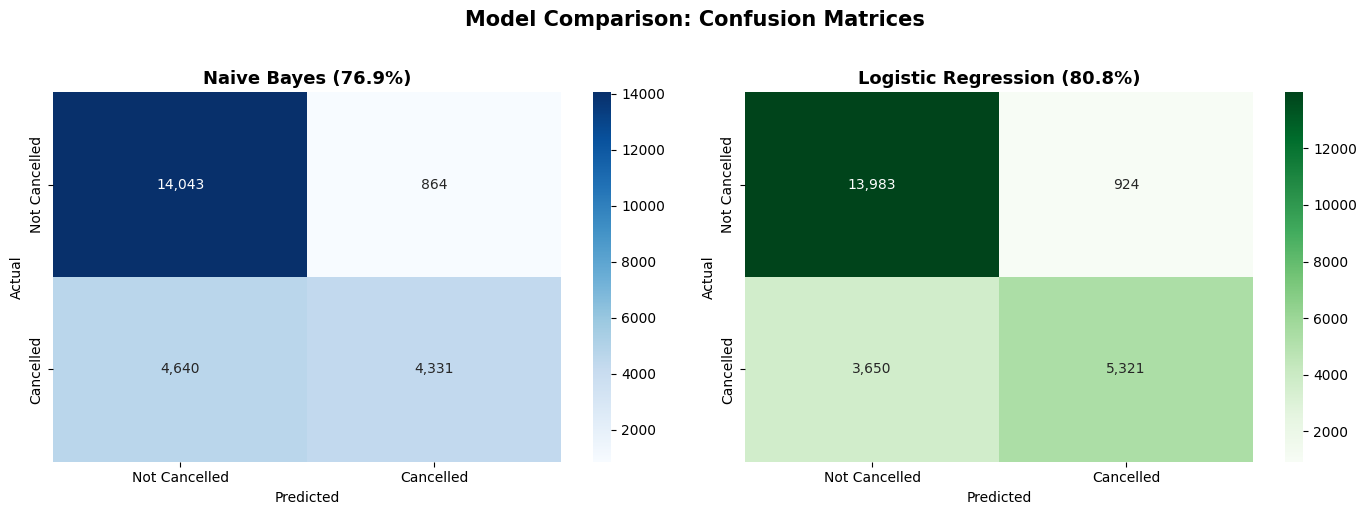

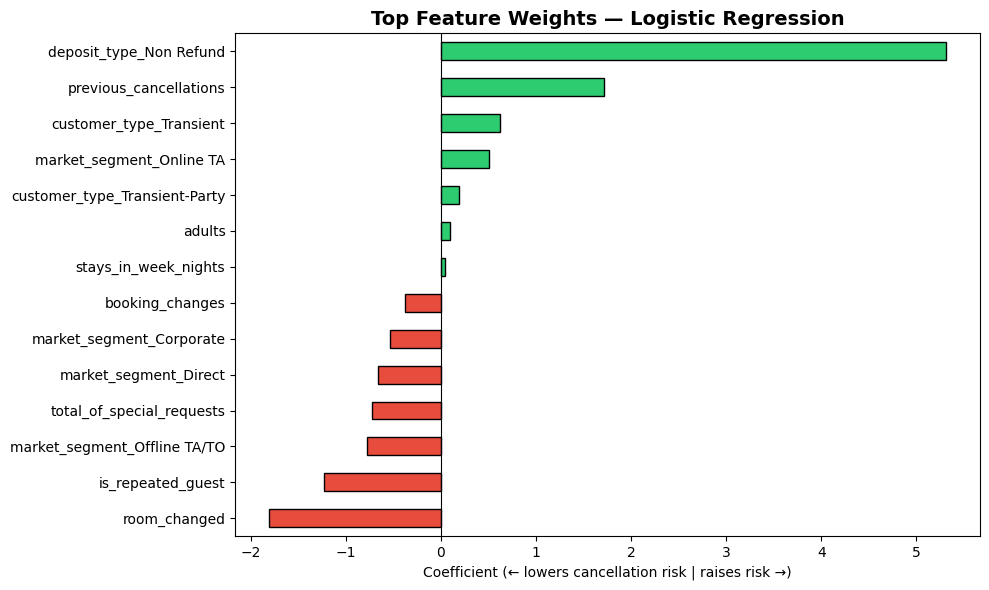


Logistic Regression outperforms Naive Bayes here because it can model feature
interactions and handle the different scales/distributions of our features more flexibly.
Naive Bayes assumes features are independent and normally distributed — assumptions
that don't fully hold for hotel booking data (e.g., deposit_type and market_segment are correlated).


In [12]:


# OPTIONAL: LOGISTIC REGRESSION COMPARISON

from sklearn.linear_model import LogisticRegression

# Train Logistic Regression (same split)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.1f}%)")
print(f"Gaussian Naive Bayes Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print(f"Improvement: {(acc_lr - acc)*100:+.1f} percentage points")

# Classification Report
print("\n--- Classification Report (Logistic Regression) ---")
print(classification_report(y_test, y_pred_lr, target_names=['Not Cancelled', 'Cancelled']))

# Confusion Matrix comparison side by side
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'], ax=axes[0])
axes[0].set_title(f'Naive Bayes ({acc*100:.1f}%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_lr, annot=True, fmt=',d', cmap='Greens',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'], ax=axes[1])
axes[1].set_title(f'Logistic Regression ({acc_lr*100:.1f}%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Model Comparison: Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Top 10 feature importances from Logistic Regression
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
top_features = pd.concat([coefs.head(7), coefs.tail(7)])
top_features.plot(kind='barh', color=['#e74c3c' if v < 0 else '#2ecc71' for v in top_features], ax=ax, edgecolor='black')
ax.set_title('Top Feature Weights — Logistic Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient (← lowers cancellation risk | raises risk →)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nLogistic Regression outperforms Naive Bayes here because it can model feature")
print("interactions and handle the different scales/distributions of our features more flexibly.")
print("Naive Bayes assumes features are independent and normally distributed — assumptions")
print("that don't fully hold for hotel booking data (e.g., deposit_type and market_segment are correlated).")


---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for the Hotel Chain:**

**1. Implement a "Commitment Check" for Long-Lead Bookings (200+ days out)**
Our data shows that bookings made 6+ months in advance cancel at roughly 60% — nearly 3x the rate of short-lead bookings. The hotel should deploy an automated confirmation email sequence at 90, 60, and 30 days before arrival, offering early check-in perks or dining credits for reconfirming. For bookings over 300 days, consider requiring a small refundable deposit. Even a 10–15% reduction in long-lead cancellations could recover hundreds of room-nights annually.

**2. Renegotiate OTA Terms or Require Deposits for High-Risk Channels**
Online Travel Agent bookings with no deposit cancel at significantly higher rates than direct bookings. The hotel should either negotiate stricter cancellation policies with key OTA partners, or implement tiered deposit requirements — no deposit for bookings under 30 days, partial deposit for 30–180 days, and non-refundable deposit for 180+ days. This alone could reduce the ~37% cancellation rate by 5–8 percentage points across the OTA channel.

**3. Invest in Repeat Guest Loyalty — They Almost Never Cancel**
Repeat guests cancel at a fraction of the rate of first-timers (~15% vs ~38%). Every dollar spent building a loyalty program — early access to room selection, complimentary upgrades, personalized welcome amenities — pays double: it increases direct bookings (reducing OTA commissions) and dramatically improves booking reliability. The hotel should flag every first-time guest who completes a stay and enroll them in a simple loyalty program with a rebooking incentive before checkout.

---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [13]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*